# 02: Reproducing Yeh & Lien (2009)

In this notebook we investigate the paper that published the Taiwan dataset:

> Yeh, I-C. & Lien, C-H. (2009). The comparisons of data mining techniques for
> the predictive accuracy of probability of default of credit card clients.
> *Expert Systems with Applications* 36(2), 2473–2480.
> https://doi.org/10.1016/j.eswa.2007.12.020

It compares six classifiers (k-nearest neighbours, logistic regression,
discriminant analysis, naive Bayes, neural networks and classification trees)
in two ways: how well each ranks customers by risk, and how close its
predicted probabilities are to the real probability of default. For the
second, the paper introduces its own method, the *Sorting Smoothing Method*.

As the paper does not contain any code, we resort to rebuilding the logistic regression model and checking results against those reported in Table 1, Table 2 and Fig. 3 from the paper. Then we go beyond the paper, using what lecture 01.2
(*Introduction to Classification*) and its R demo suggests a classifier should be
judged on. The R demo's plots are translated into Python and
changed where they didn't work on this data.

Some steps use theory from another unit's lecture notes:

> Maullin, T. (2026). *MATH30028 Statistical Machine Learning, Part I*,
> lecture notes (last updated 15 January 2026). University of Bristol.
> Available to University of Bristol students and staff on the MATH30028
> Blackboard page.

Short "Link to MATH30028" notes give the section number in those notes
(e.g. §3.1.3), so each point can be checked against the source.

| Step | What | Compared with |
|---|---|---|
| 0 | Split into train / calibration / test | lecture 01.2 |
| 1 | The paper's model: logistic regression, all 23 columns, no penalty | paper, §3 |
| 2 | Error rate and area ratio | paper, Table 1 |
| 3 | Lift chart | paper, Fig. 3; R demo |
| 4 | Precision and recall, and choosing a threshold | lecture 01.2 |
| 5 | Are the scores probabilities? | paper, Table 2 (Sorting Smoothing Method) |

Run `01-Introduction.ipynb` first. It makes `data/processed/taiwan-clean.csv`,
which this notebook loads.

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent            # notebooks run from report/
taiwan = pd.read_csv(ROOT / "data" / "processed" / "taiwan-clean.csv", index_col="ID")
Y = "default payment next month"
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"

print(taiwan.shape)                      # expect (29995, 24): 23 columns + the label
print(f"default rate {taiwan[Y].mean():.3f}")

(29995, 24)
default rate 0.221


## Step 0: three-way split

The paper splits its data into training and validation sets, but doesn't say
what sizes. Lecture 01.2 suggests three parts:

| Part | Share | Used for |
|---|---|---|
| train | 60% | fitting the model |
| calibration | 20% | checking whether the scores behave like probabilities, and choosing a threshold |
| test | 20% | the final scores, looked at once, so choices made on it can't flatter them |

`train_test_split` makes two parts, so we call it twice. `stratify` keeps the
22% default rate the same in every part, and `random_state=0` makes the split
the same on every run.

In [20]:
X = taiwan.drop(columns=Y)
y = taiwan[Y]

X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=0)   # 25% of 80% = 20%

pd.DataFrame({
    "rows": [len(y_train), len(y_cal), len(y_test)],
    "default rate": np.round([y_train.mean(), y_cal.mean(), y_test.mean()], 3),
}, index=["train", "calibration", "test"])

,rows,default rate
train,17997,0.221
calibration,5999,0.221
test,5999,0.221


## Step 1: the paper's model

The paper fits a logistic regression on all 23 columns and doesn't mention a
penalty. The lecture's R demo uses `glm(..., family = binomial)`, which has
none either. scikit-learn's `LogisticRegression`, though, adds a small L2 norm
("ridge") penalty by default (`C=1.0`), which pulls the weights towards 0. To
match the paper we turn it off with `C=np.inf` (the penalty's strength is
1/C).


We fit both versions on the train set and compare them on the calibration set,
to see whether the penalty matters. `StandardScaler` puts every column on the
same scale first. That helps the fitting converge, and makes each weight the
change in log-odds for a one-standard-deviation change in its column.

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

paper   = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000))  # no penalty
default = make_pipeline(StandardScaler(), LogisticRegression(C=1.0,    max_iter=5000))  # scikit-learn default
paper.fit(X_train, y_train)
default.fit(X_train, y_train)

p_cal_paper = paper.predict_proba(X_cal)[:, 1]      # predicted probability of default
gap = np.abs(p_cal_paper - default.predict_proba(X_cal)[:, 1])

print(f"calibration AUC   no penalty {roc_auc_score(y_cal, p_cal_paper):.4f}"
      f"   C=1 {roc_auc_score(y_cal, default.predict_proba(X_cal)[:, 1]):.4f}")
print(f"difference in predicted probability   largest {gap.max():.4f}   average {gap.mean():.5f}")

calibration AUC   no penalty 0.7263   C=1 0.7263
difference in predicted probability   largest 0.0046   average 0.00011


Interestingly, the penalty makes no practical difference. The AUC is identical to four decimal places, and the predicted probabilities differ by about 0.0001 on
average. With 18,000 training rows and only 23 weights, the data outweighs the small penalty term. From here on we use the unpenalised model, as the paper does.

### Investigating the model weights

The bill columns get large weights with opposite signs: a higher September
bill (`BILL_AMT1`) *lowers* the predicted risk, while a higher August bill
(`BILL_AMT2`) *raises* it. Figure 2.1 shows why that shouldn't be taken at
face value.

Weights of the bill columns (change in log-odds per 1 SD):
BILL_AMT1   -0.410
BILL_AMT2    0.271
BILL_AMT3    0.070
BILL_AMT4   -0.054
BILL_AMT5   -0.001
BILL_AMT6    0.037


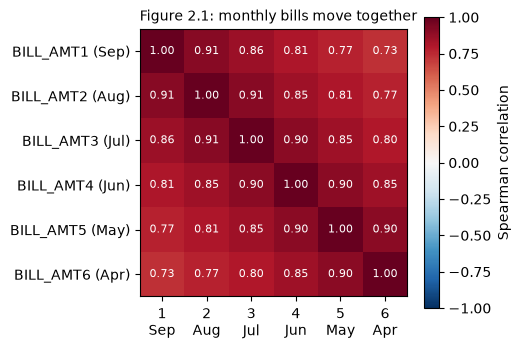

In [22]:
weights = pd.Series(paper[-1].coef_[0], index=X.columns)
print("Weights of the bill columns (change in log-odds per 1 SD):")
print(weights.filter(like="BILL_AMT").round(3).to_string())

bills = [f"BILL_AMT{i}" for i in range(1, 7)]
corr = X_train[bills].corr(method="spearman")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white")                   # every cell is > 0.7, so dark
months = ["Sep", "Aug", "Jul", "Jun", "May", "Apr"]
ax.set_xticks(range(6), [f"{b[-1]}\n{m}" for b, m in zip(bills, months)])
ax.set_yticks(range(6), [f"BILL_AMT{b[-1]} ({m})" for b, m in zip(bills, months)])
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
ax.set_title("Figure 2.1: monthly bills move together", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

Figure 2.1: Spearman (rank) correlation between the six monthly bill
amounts, on the train set.


Neighbouring months correlate at about 0.9, so a customer's September bill
nearly tells you their August bill. When columns are this close to copies of
each other, the model can move weight between them with almost no change in
fit. A large negative weight on one and a large positive weight on the next
mostly cancel. Only their combined effect means anything, and a single
bill weight's sign shouldn't be interpreted.

## Step 2: the paper's Table 1, error rate and area ratio

The paper scores each method in two ways, on training and validation data. Its
validation data plays the role of our test set, so this is where we look at
the test set.

* Error rate: the share of customers put in the wrong class. We predict
  "default" when p > 0.5. The paper doesn't state a threshold, and 0.5 is the
  usual default, as in the R demo.
* Area ratio: from the lift chart (step 3). Sort customers from riskiest to
  safest, and plot the share of customers checked (x) against the share of
  defaulters caught (y). Then

$$\text{area ratio} = \frac{\text{area between model and random order}}
{\text{area between best possible order and random order}}$$

0 means no better than random and 1 means perfect. In credit scoring the same
number is called the accuracy ratio or Gini coefficient, and it always
equals 2 × AUC − 1 (Engelmann, Hayden & Tasche, 2003). We compute it from
the curve, as the paper does, and check it against the AUC. With default rate
$\pi$, the random-order line encloses area 1/2 and the best curve
$\min(x/\pi, 1)$ encloses $1 - \pi/2$, so the denominator is $(1-\pi)/2$.

In [23]:
def gains_curve(y_true, p):
    """Lift (gains) chart: share of customers checked (x) vs share of defaulters caught (y),
    checking customers from highest to lowest predicted risk."""
    y_sorted = np.asarray(y_true)[np.argsort(-p, kind="stable")]
    x = np.arange(len(y_sorted) + 1) / len(y_sorted)
    caught = np.concatenate([[0], np.cumsum(y_sorted)]) / y_sorted.sum()
    return x, caught

def area_ratio(y_true, p):
    """Yeh & Lien's area ratio: (model area - random area) / (best area - random area)."""
    x, caught = gains_curve(y_true, p)
    pi = np.mean(y_true)
    return (np.trapezoid(caught, x) - 0.5) / ((1 - pi) / 2)

def error_rate(y_true, p, threshold=0.5):
    return np.mean((p > threshold) != np.asarray(y_true))

p_train = paper.predict_proba(X_train)[:, 1]
p_test  = paper.predict_proba(X_test)[:, 1]      # the one look at the test set

table1 = pd.DataFrame({
    "error rate, training":   [0.20, error_rate(y_train, p_train)],
    "error rate, validation": [0.18, error_rate(y_test,  p_test)],
    "area ratio, training":   [0.41, area_ratio(y_train, p_train)],
    "area ratio, validation": [0.44, area_ratio(y_test,  p_test)],
}, index=["Yeh & Lien (2009), Table 1", "ours (validation = our test set)"])
display(table1.round(3))

print(f"check: area ratio {area_ratio(y_test, p_test):.6f} = 2*AUC-1 {2 * roc_auc_score(y_test, p_test) - 1:.6f}")
print(f"error rate of always saying 'no default': {y_test.mean():.3f}")

,"error rate, training","error rate, validation","area ratio, training","area ratio, validation"
"Yeh & Lien (2009), Table 1",0.20,0.180,0.410,0.440
ours (validation = our test set),0.19,0.188,0.455,0.425


check: area ratio 0.424844 = 2*AUC-1 0.424844
error rate of always saying 'no default': 0.221


### How much of the gap is the luck of the data split?

One test set is one random draw of customers, and a different draw gives
slightly different scores. To see how big that discrepancy is, we repeat the
paper's set-up (an 80/20 train/validation split) with 20 different seeds.


In [24]:
repeats = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    m = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000)).fit(Xa, ya)
    pb = m.predict_proba(Xb)[:, 1]
    repeats.append({"error rate": error_rate(yb, pb), "area ratio": area_ratio(yb, pb)})

pd.DataFrame(repeats).agg(["mean", "std", "min", "max"]).round(3)

,error rate,area ratio
mean,0.190,0.440
std,0.003,0.010
min,0.186,0.420
max,0.196,0.459


What matched:

* Our test set gives 0.425 against the paper's
  0.44. Over 20 splits the average is 0.440, exactly the paper's, with a
  range of 0.42–0.46. Our single test set just falls at the low end.
* The area ratio is the AUC in other units - they agree to six decimal
  places. So the paper's measure and the AUC used in lecture 01.2 always rank
  models the same way.

What didn't match:

* The error rate is slightly higher, 0.188 against 0.18, and even the best
  of 20 splits gives 0.186. The paper's data may differ (it reports 25,000
  customers; the file has 30,000), or 0.18 may be rounded. The paper doesn't
  give enough detail to tell.
* The paper's training area ratio (0.41) is below its validation score
  (0.44). Ours is the usual way round (0.455 training, 0.425 test). That's
  possible by chance with one split, but the paper doesn't comment on it.

Its worth noting here that simply saying "no default" to everyone gives
an error rate of 0.221, and the model only improves that to 0.188. The paper
says so itself (error rate is "insensitive" when most customers don't
default), and so does lecture 01.2. That is why the next steps look at the
whole ranking, and then at the probabilities.

## Step 3: the paper's Fig. 3, a lift chart

Figure 2.2 uses the
paper's axes (counts, not shares): customers checked, riskiest first, against
defaulters caught. The shading is the ratio itself, orange area ÷ (orange +
grey). Compare it with Yeh & Lien (2009), Fig. 3 (p. 2476). Their x-axis
counts their validation set, whose size isn't stated, so compare the shape
rather than the counts.

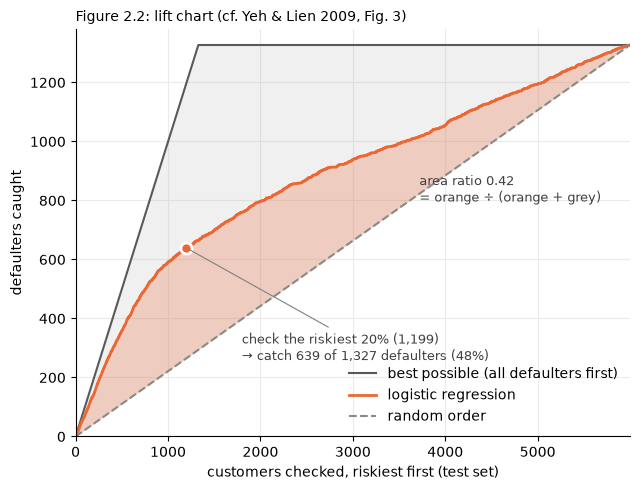

In [25]:
x, caught = gains_curve(y_test, p_test)
n, n_def = len(y_test), int(y_test.sum())
pi = n_def / n
checked, found = x * n, caught * n_def            # shares -> counts, as on the paper's axes
best = np.minimum(checked, n_def)                 # every defaulter first, then flat
k20 = int(0.2 * n)                                # the riskiest 20% of customers

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.fill_between(checked, checked * pi, best, color=GREY, alpha=0.12, linewidth=0)
ax.fill_between(checked, checked * pi, found, color=ORANGE, alpha=0.25, linewidth=0)
ax.plot(checked, best, color="0.35", linewidth=1.5, label="best possible (all defaulters first)")
ax.plot(checked, found, color=ORANGE, linewidth=2, label="logistic regression")
ax.plot(checked, checked * pi, color=GREY, linestyle="--", linewidth=1.5, label="random order")

ax.plot(k20, found[k20], "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=2)
ax.annotate(f"check the riskiest 20% ({k20:,})\n→ catch {found[k20]:,.0f} of {n_def:,} defaulters ({caught[k20]:.0%})",
            xy=(k20, found[k20]), xytext=(k20 + 600, found[k20] - 380), fontsize=9, color="0.25",
            arrowprops=dict(arrowstyle="-", color="0.5", linewidth=0.8))
ax.text(n * 0.62, n_def * 0.60, f"area ratio {area_ratio(y_test, p_test):.2f}\n= orange ÷ (orange + grey)",
        fontsize=9, color="0.25")

ax.set_xlim(0, n); ax.set_ylim(0, n_def * 1.04)
ax.set_xlabel("customers checked, riskiest first (test set)")
ax.set_ylabel("defaulters caught")
ax.set_title("Figure 2.2: lift chart (cf. Yeh & Lien 2009, Fig. 3)", loc="left", fontsize=10)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="0.92"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### The same ranking as the lecture 01.2 R demo draws it

The R demo plots each test case's prediction score against its rank,
coloured by the true class. Copied directly, this doesn't work with 6,000
customers: sorting by score puts every point on one curve, and the defaulters
hide under everyone else. So Figure 2.3 splits it in two. The top panel is the
score curve from riskiest to safest. The bottom panel has one thin orange line
at the rank of each customer who actually defaulted.

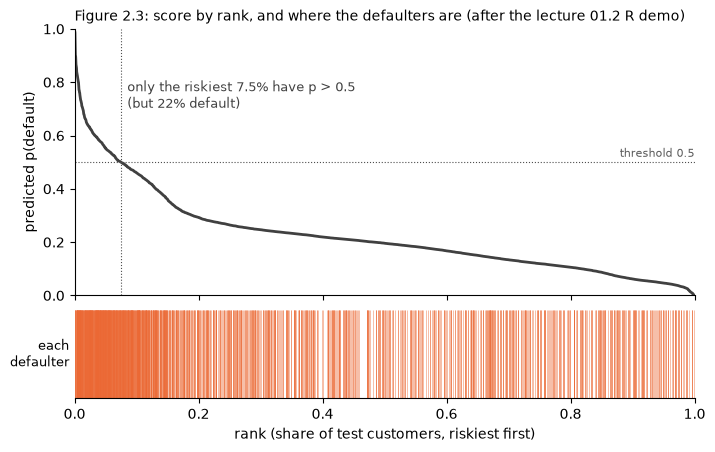

In [26]:
order = np.argsort(-p_test, kind="stable")
rank = np.arange(1, n + 1) / n                    # near 0 = riskiest, 1 = safest
p_sorted, y_sorted = p_test[order], np.asarray(y_test)[order]
flagged = np.mean(p_test > 0.5)

fig, (top, strip) = plt.subplots(2, 1, figsize=(8, 4.8), sharex=True,
                                 gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
top.plot(rank, p_sorted, color="0.25", linewidth=2)
top.axhline(0.5, color="0.3", linewidth=0.8, linestyle=":")
top.axvline(flagged, color="0.3", linewidth=0.8, linestyle=":")
top.text(flagged + 0.01, 0.75, f"only the riskiest {flagged:.1%} have p > 0.5\n(but {y_test.mean():.0%} default)",
         fontsize=9, color="0.25", va="center")
top.text(1.0, 0.51, "threshold 0.5", ha="right", va="bottom", fontsize=8, color="0.35")
top.set_ylim(0, 1)
top.set_ylabel("predicted p(default)")
top.set_title("Figure 2.3: score by rank, and where the defaulters are (after the lecture 01.2 R demo)",
              loc="left", fontsize=10)

strip.eventplot(rank[y_sorted == 1], colors=ORANGE, linewidths=0.6, alpha=0.5, lineoffsets=0.5, linelengths=1)
strip.set_yticks([]); strip.set_ylim(0, 1)
strip.set_ylabel("each\ndefaulter", rotation=0, ha="right", va="center", fontsize=9)
strip.set_xlim(0, 1)
strip.set_xlabel("rank (share of test customers, riskiest first)")
for a in (top, strip):
    a.spines[["top", "right"]].set_visible(False)
strip.spines["left"].set_visible(False)
plt.show()

The model ranks well at the top, then fades. Checking the riskiest 20% of
customers catches 48% of defaulters, against 20% in random order. Below the
top 40%, though, customers still default at 13%, so about a third of all
defaulters are spread through the part of the ranking the model calls "safe".
In Figure 2.3 the strip is solid on the left, then a thinner, even scatter.

It seems the 0.5 threshold uses only the very top of the ranking. Only 7.5% of
customers score above 0.5, although 22% default. Of those, 72% do default, but
they are only a quarter of all defaulters. That is why the error rate barely
beat "no default for everyone", at 0.5 the model hardly ever says "default".

## Step 4: precision, recall and choosing a threshold 

Lecture 01.2 adds the
precision–recall curve, the right view "when we care specifically about
positive cases" (Davis & Goadrich, 2006). Here the positive cases are the
defaulters. If we flag everyone with p above a threshold:

* recall = share of all defaulters we flag (the "defaulters caught" of the lift chart);
* precision = share of the flagged customers who really default.

Note that random guessing has precision 0.22 (the default rate) at every recall.

Instead of 0.5, we pick the threshold with the best
F1 score, $F_1 = 2PR/(P+R)$, which balances precision and recall. It is
chosen on the calibration set and only then scored on the test set.

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Choose the threshold on the CALIBRATION set: the one with the highest F1.
#    The curve's last point (recall 0) has no threshold, so it is skipped.
prec_c, rec_c, thr_c = precision_recall_curve(y_cal, p_cal_paper)
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1])
t_star = thr_c[np.nanargmax(f1_c)]

# 2. Score both thresholds on the TEST set.
def scores_at(y_true, p, threshold):
    y_true = np.asarray(y_true)
    flag = p >= threshold
    precision = y_true[flag].mean()
    recall = y_true[flag].sum() / y_true.sum()
    return {"share flagged": flag.mean(), "precision": precision, "recall": recall,
            "F1": 2 * precision * recall / (precision + recall),
            "error rate": np.mean(flag != y_true)}

pd.DataFrame({"threshold 0.5": scores_at(y_test, p_test, 0.5),
              f"threshold {t_star:.2f} (from calibration set)": scores_at(y_test, p_test, t_star)}).T.round(3)

,share flagged,precision,recall,F1,error rate
threshold 0.5,0.075,0.724,0.246,0.367,0.188
threshold 0.31 (from calibration set),0.185,0.558,0.466,0.508,0.200


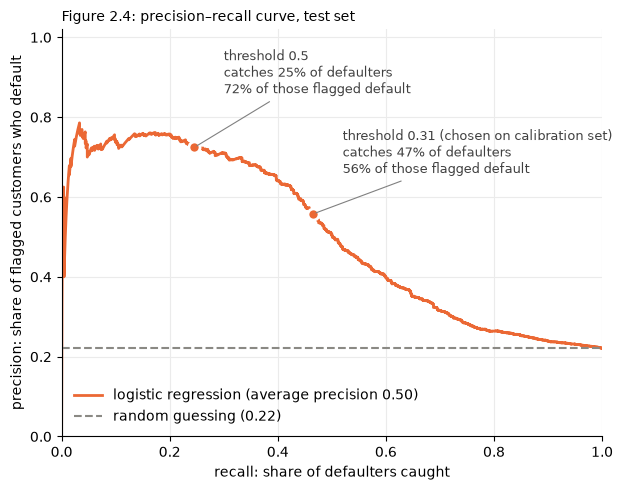

In [28]:
prec, rec, _ = precision_recall_curve(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(rec[:-1], prec[:-1], color=ORANGE, linewidth=2, label=f"logistic regression (average precision {ap:.2f})")
ax.axhline(y_test.mean(), color=GREY, linestyle="--", linewidth=1.5, label=f"random guessing ({y_test.mean():.2f})")

for th, name, text_at in [(0.5, "threshold 0.5", (0.30, 0.86)),
                          (t_star, f"threshold {t_star:.2f} (chosen on calibration set)", (0.52, 0.66))]:
    s = scores_at(y_test, p_test, th)
    ax.plot(s["recall"], s["precision"], "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=2)
    ax.annotate(f"{name}\ncatches {s['recall']:.0%} of defaulters\n{s['precision']:.0%} of those flagged default",
                xy=(s["recall"], s["precision"]), xytext=text_at, fontsize=9, color="0.25",
                arrowprops=dict(arrowstyle="-", color="0.5", linewidth=0.8))

ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel("recall: share of defaulters caught")
ax.set_ylabel("precision: share of flagged customers who default")
ax.set_title("Figure 2.4: precision–recall curve, test set", loc="left", fontsize=10)
ax.legend(frameon=False, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="0.92"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

We see that moving the threshold nearly doubles the defaulters caught. The threshold
chosen on the calibration set (0.31) catches 47% of defaulters on the test
set, against 25% at 0.5. This is at the cost of more false alarms -  precision falls from
72% to 56%. F1 rises from 0.37 to 0.51.

The error rate also worsens (0.188 → 0.200). By one of the paper's
two measures, the more useful threshold looks like the poorer model. Error
rate counts a missed defaulter and a false alarm as equally bad, and there are
far more non-defaulters to get wrong.

Its also worth noting that the model is the same at both thresholds. Area ratio, AUC and average
precision (0.50, against 0.22 for random guessing) judge the ranking and
don't depend on the threshold.

## Step 5: are the scores probabilities?

Steps 2–4 judged only the ranking. The paper's main argument is that this
isn't enough: for managing risk, the predicted *probability* of default matters
more than a yes/no class. If the model gives a group of customers p = 0.2, do
about 20% of them default? A model that does this is calibrated.

### The Sorting Smoothing Method (SSM)

Sort customers by predicted p. For customer $i$, estimate the "real"
probability of default as the share of defaulters among them and their $n$
neighbours on each side:

$$P_i = \frac{Y_{i-n} + \dots + Y_i + \dots + Y_{i+n}}{2n + 1},$$

with $Y = 1$ for a default. The paper uses $n = 50$, so each estimate averages
101 customers: a moving average of the outcomes along the sorted list. The first and last 50 customers have
no full window, so we leave them out. Unfortunately, the paper doesn't say what it did for these datapoints.

The paper then fits a straight line, real = A + B × predicted. A calibrated
model gives B = 1, A = 0, and R² measures how close the points lie to the
line. For logistic regression its Table 2 reports B = 1.233, A = −0.0523,
R² = 0.794.

As planned in step 0, the check is done on the calibration set. The test
set is shown alongside for comparison.

In [29]:
def ssm(y_true, p, n=50):
    """Yeh & Lien's Sorting Smoothing Method: sort by p, then a moving average of the
    outcomes over 2n+1 customers. Returns (predicted p, estimated real p), full windows only."""
    order = np.argsort(p, kind="stable")
    p_sorted, y_sorted = p[order], np.asarray(y_true)[order]
    window = 2 * n + 1
    real = np.convolve(y_sorted, np.ones(window) / window, mode="valid")
    return p_sorted[n:len(p_sorted) - n], real

def ssm_line(y_true, p, n=50):
    """Fit real = A + B * predicted, as in the paper's Table 2."""
    pred, real = ssm(y_true, p, n)
    B, A = np.polyfit(pred, real, 1)                  # polyfit returns the slope first
    return {"slope B": B, "intercept A": A, "R²": np.corrcoef(pred, real)[0, 1] ** 2}

pd.DataFrame({
    "Yeh & Lien (2009), Table 2": {"slope B": 1.233, "intercept A": -0.0523, "R²": 0.794},
    "ours, calibration set":      ssm_line(y_cal, p_cal_paper),
    "ours, test set":             ssm_line(y_test, p_test),
}).T.round(4)

,slope B,intercept A,R²
"Yeh & Lien (2009), Table 2",1.2330,-0.0523,0.7940
"ours, calibration set",1.1483,-0.0338,0.8382
"ours, test set",1.1190,-0.0280,0.8085


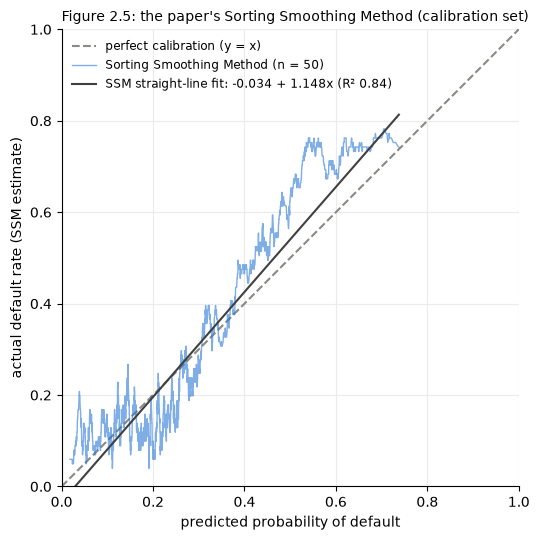

In [30]:
pred, real = ssm(y_cal, p_cal_paper)
line = ssm_line(y_cal, p_cal_paper)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.5, label="perfect calibration (y = x)")
ax.plot(pred, real, color=BLUE, linewidth=1, alpha=0.6, label="Sorting Smoothing Method (n = 50)")
xs = np.array([pred.min(), pred.max()])
ax.plot(xs, line["intercept A"] + line["slope B"] * xs, color="0.25", linewidth=1.5,
        label=f"SSM straight-line fit: {line['intercept A']:.3f} + {line['slope B']:.3f}x (R² {line['R²']:.2f})")

ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_xlabel("predicted probability of default")
ax.set_ylabel("actual default rate (SSM estimate)")
ax.set_title("Figure 2.5: the paper's Sorting Smoothing Method (calibration set)", loc="left", fontsize=10)
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="0.92"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

We see that we have reproduced the paper's pattern. The slope is above 1 and the intercept
is below 0, as in its Table 2: B = 1.15 (theirs 1.23), A = −0.034 (theirs
−0.052), R² = 0.84 (theirs 0.79). 

But the SSM curve itself isn't a straight line. In Figure 2.5 the blue
curve crosses the diagonal in an S shape:

* below p ≈ 0.15, more customers default than predicted: those predicted
  about 4% default at about 12%;
* from about 0.15 to 0.30, fewer default than predicted: those predicted
  about 22% default at about 14%;
* above about 0.30, more default than predicted again: those predicted
  about 58% default at about 72%.

A single A and B can't describe this. The fitted line averages over errors in
opposite directions. The
paper reports only the line, so its Table 2 would hide a shape like this.

Notebook 03 takes up the obvious next question: can the probabilities be
*fixed*?

## Summary

| | Yeh & Lien (2009) | Our atempt | Verdict |
|---|---|---|---|
| Area ratio, validation | 0.44 | 0.425 (mean of 20 splits 0.440) | reproduced |
| Error rate, validation | 0.18 | 0.188 (best of 20 splits 0.186) | close, slightly worse |
| Lift chart shape | Fig. 3 | Figure 2.2 | same shape |
| SSM line, slope / intercept | 1.233 / −0.052 | 1.148 / −0.034 | same pattern |
| SSM R² | 0.794 | 0.838 | close |


## References

* Davis, J. & Goadrich, M. (2006). The relationship between precision-recall
  and ROC curves. *Proceedings of the 23rd International Conference on Machine
  Learning*, 233–240. https://doi.org/10.1145/1143844.1143874
* Engelmann, B., Hayden, E. & Tasche, D. (2003). Testing rating accuracy.
  *Risk* 16 (January), 82–86.
* Hofmann, H. (1994). *Statlog (German Credit Data)* [dataset]. UCI Machine
  Learning Repository. https://doi.org/10.24432/C5NC77
* Lawson, D. (2026). *Introduction to Classification*, Data Science Toolbox
  lecture 01.2 (v4.0.0), slides and reference R code. University of Bristol.
  https://dsbristol.github.io/dst/assets/slides/01.2-Classification.pdf
* Maullin, T. (2026). *MATH30028 Statistical Machine Learning, Part I*,
  lecture notes (last updated 15 January 2026). University of Bristol.
  Available to University of Bristol students and staff on the MATH30028
  Blackboard page.
* Pedregosa, F. et al. (2011). Scikit-learn: machine learning in Python.
  *Journal of Machine Learning Research* 12, 2825–2830. (Version 1.9.1 used.)
* Yeh, I-C. & Lien, C-H. (2009). The comparisons of data mining techniques for
  the predictive accuracy of probability of default of credit card clients.
  *Expert Systems with Applications* 36(2), 2473–2480.
  https://doi.org/10.1016/j.eswa.2007.12.020

Full working, including dead ends: [`Oscar/07-yeh-lien.ipynb`](../Oscar/07-yeh-lien.ipynb).